In [1]:
%run -i ../../python_scripts/nb_setup.py

GPU Available: True
GPU Name: NVIDIA GeForce RTX 4060


In [2]:
sgp_df_SR = pickle.load(open('sgp_set_resnet','rb')) 
print(sgp_df_SR.shape)
print('1s prop = ', sgp_df_SR.y_true.sum()/sgp_df_SR.shape[0])
sgp_df_SR.head() 

(40000, 3)
1s prop =  0.09895


,y_true,y_pred,kappa
0,0.0,0.0,0.999986
1,0.0,0.0,0.999986
2,0.0,0.0,0.999990
3,0.0,0.0,0.999980
4,0.0,0.0,0.999816


In [3]:
train_set_SR, test_set_SR = train_test_split(sgp_df_SR, seed=17) # drawing 3/4 for bounds fitting, 1/4 for bounds testing

In [4]:
delta = 0.005
greedy_search_steps_num = 50 # increase number of search steps for more precise metrics bounds

In [5]:
color_map = {'standard': "#d51414",
             'FP': "#8F7A1C",
             'FN': "#0f770a",
             'FPR': "#403535",
             'FNR': "#1d3ae2",
             'SE': "#93139c",
             'SP': "#0F8592",
             'PPV': "#676767"}

### Joint evolution of metrics with respect to $\theta$

standard  bounds


 98%|█████████▊| 49/50 [00:03<00:00, 14.06it/s]


FP  bounds


 98%|█████████▊| 49/50 [00:00<00:00, 106.20it/s]


FN  bounds


...

 98%|█████████▊| 49/50 [00:00<00:00, 110.60it/s]


SE  bounds


 98%|█████████▊| 49/50 [00:03<00:00, 15.98it/s]


SP  bounds


 98%|█████████▊| 49/50 [00:00<00:00, 103.68it/s]


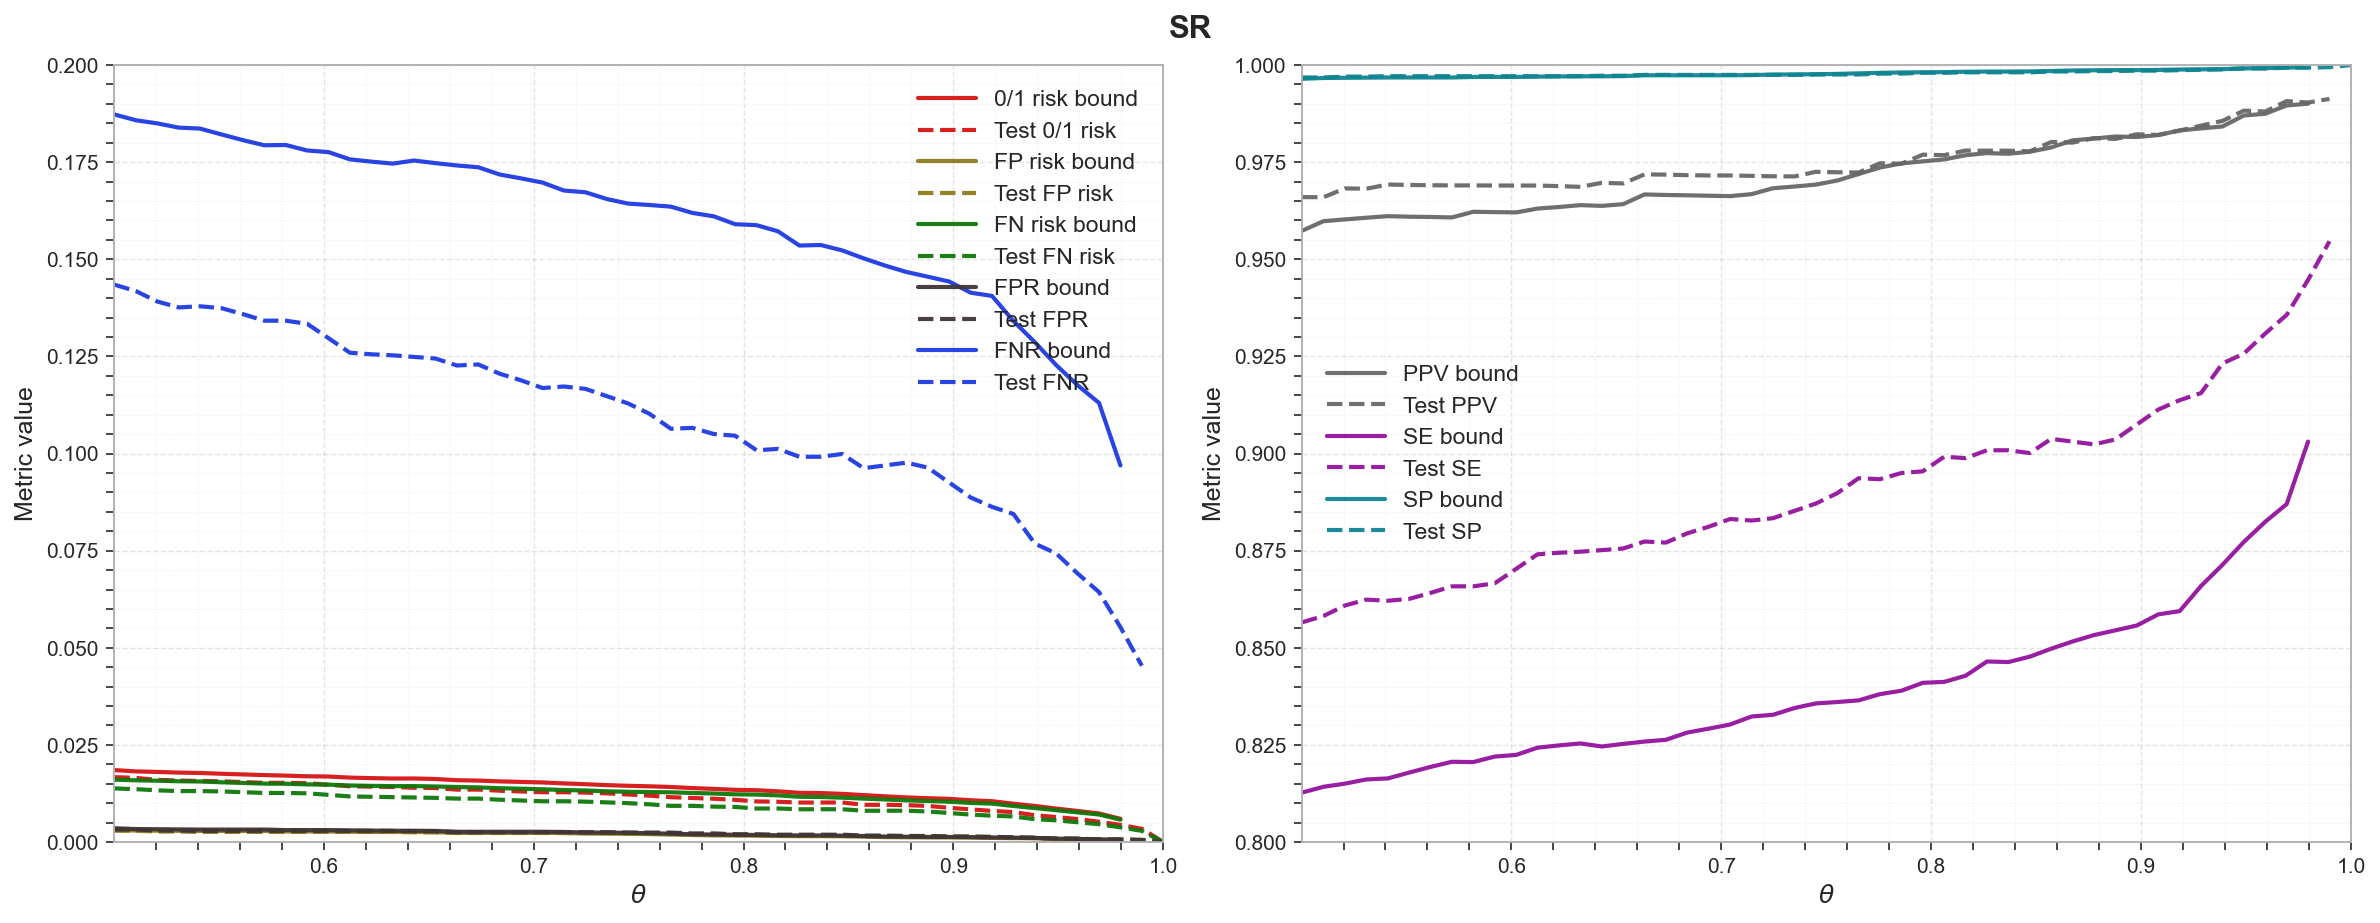

In [6]:
plot_all_metrics(train_set_SR, test_set_SR,
                 delta, color_map, title='SR',
                 ylim1=[0,0.2], ylim2=[0.8,1])

standard  bounds


 98%|█████████▊| 49/50 [00:03<00:00, 13.98it/s]


FP  bounds


 98%|█████████▊| 49/50 [00:00<00:00, 105.58it/s]


FN  bounds


...

 98%|█████████▊| 49/50 [00:00<00:00, 105.38it/s]


SE  bounds


 98%|█████████▊| 49/50 [00:03<00:00, 15.47it/s]


SP  bounds


 98%|█████████▊| 49/50 [00:00<00:00, 102.72it/s]


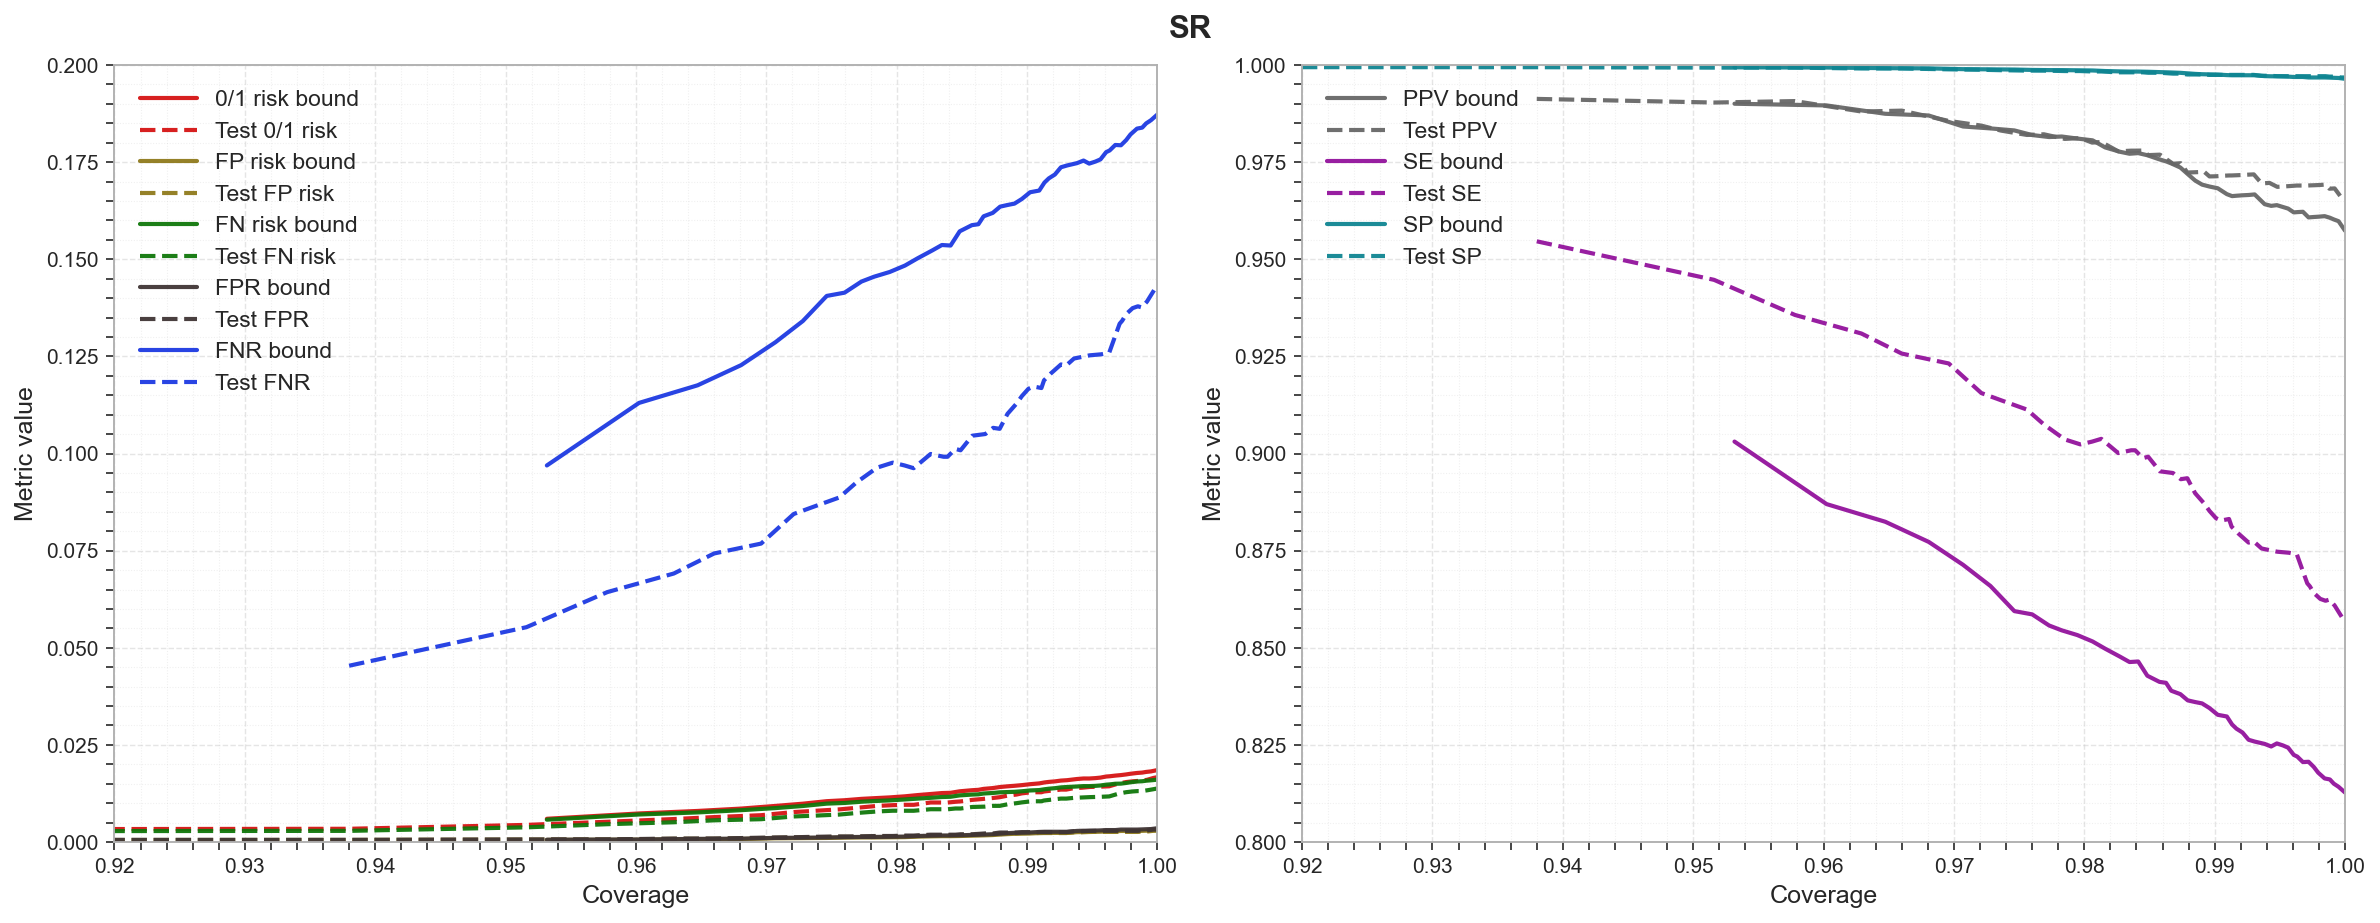

In [7]:
plot_all_metrics(train_set_SR, test_set_SR,
                 delta, color_map, title='SR',
                 ylim1=[0,0.2], ylim2=[0.8,1],
                 xlim1=[0.92,1],xlim2=[0.92,1],
                 by_coverage=True)

### Find best $\theta$ in the intersection of metrics $\theta$ regions, if non empty

In [8]:
metrics_and_targets = {'FNR' : 0.2,
                       'FPR' : 0.1}

In [9]:
joint_output = joint_control(metrics_and_targets, train_set_SR, delta, plot=False)
joint_output

FNR  bounds


 99%|█████████▉| 99/100 [00:06<00:00, 15.60it/s]


FPR  bounds


 99%|█████████▉| 99/100 [00:00<00:00, 110.07it/s]


{'theta_intervals': [(np.float64(0.5002623200416565),
   np.float64(0.9899042892937708))],
 'best_theta': np.float64(0.5002623200416565)}

### All reachable bounds for a couple of 2 metrics

In [10]:
metrics = ['standard', 'FP', 'FN', 'FPR',
           'FNR','PPV', 'SE','SP']

all_bounds_SR = reachable_bounds(metrics, train_set_SR, delta, steps=100)

standard  bounds


 99%|█████████▉| 99/100 [00:07<00:00, 13.81it/s]


FP  bounds


 99%|█████████▉| 99/100 [00:00<00:00, 113.93it/s]


FN  bounds


...

 99%|█████████▉| 99/100 [00:00<00:00, 109.21it/s]


SE  bounds


 99%|█████████▉| 99/100 [00:06<00:00, 15.58it/s]


SP  bounds


 99%|█████████▉| 99/100 [00:00<00:00, 107.89it/s]


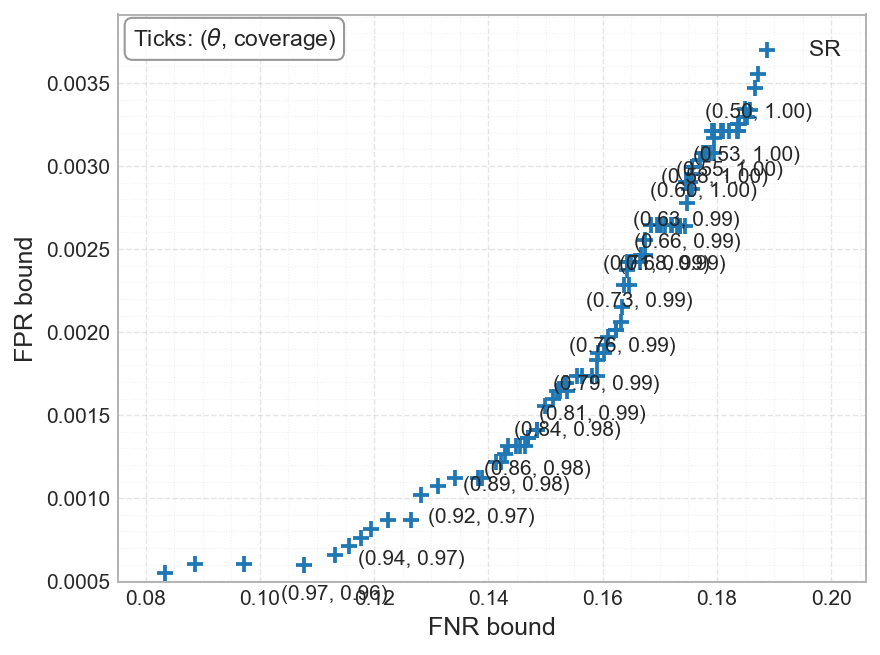

In [11]:
metric1 = 'FNR'
metric2 = 'FPR'

two_metrics_bounds(metric1, metric2, all_bounds_SR, all_bounds_MCD=None, num_labels=20)